# 02 · Bayesian vs production models (WRMSSE + accuracy)

Compare **Bayes-NegBin** rolling-origin CV against the repo's existing
`artifacts/cv_*.parquet` outputs (Theta, AutoETS, SeasonalNaive, LightGBM).

**Scope:** capped panel — MCMC per series is expensive. Defaults to 15 series
× 1 CV window. Increase `EVAL_N_SERIES` only on a beefier machine.

**Prerequisites**

```bash
uv sync --group bayesian
make prep                    # data/processed/long.parquet
make cv-stats cv-lgbm        # artifacts/cv_stats.parquet, cv_lgbm.parquet
```

Outputs the same metrics as `06_score.ipynb`: bottom-level **WRMSSE** plus
MAE / RMSE / sMAPE / bias.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from m5.config import SETTINGS
from m5.cv import bayesian_cv
from m5.evaluation import accuracy_for_models, compute_components, wrmsse_for_models
from m5.plots import configure_style

configure_style()

HORIZON = SETTINGS.horizon
N_WINDOWS = 1  # keep MCMC wall-clock reasonable locally
EVAL_N_SERIES = 15
MCMC_DRAWS = 600
MCMC_TUNE = 600

ARTIFACTS = SETTINGS.artifacts_dir
LONG_PARQUET = SETTINGS.processed_dir / "long.parquet"
CV_STATS = ARTIFACTS / "cv_stats.parquet"
CV_LGBM = ARTIFACTS / "cv_lgbm.parquet"
CV_BAYES_OUT = ARTIFACTS / "cv_bayes.parquet"

## 1 · Load truth + existing CV artifacts

In [3]:
for path in (LONG_PARQUET, CV_STATS, CV_LGBM):
    if not path.exists():
        raise FileNotFoundError(f"Missing {path} — run make prep / cv-* first.")

long = pd.read_parquet(LONG_PARQUET)
long["ds"] = pd.to_datetime(long["ds"])

stats_cv = pd.read_parquet(CV_STATS)
stats_cv["ds"] = pd.to_datetime(stats_cv["ds"])
stats_cv["cutoff"] = pd.to_datetime(stats_cv["cutoff"])

lgbm_cv = pd.read_parquet(CV_LGBM)
lgbm_cv["ds"] = pd.to_datetime(lgbm_cv["ds"])
lgbm_cv["cutoff"] = pd.to_datetime(lgbm_cv["cutoff"])

# Evaluate on the intersection of series present in both artifact sets.
common_ids = sorted(set(stats_cv["unique_id"]).intersection(lgbm_cv["unique_id"]))
eval_ids = common_ids[:EVAL_N_SERIES]

print(f"long: {long['unique_id'].nunique():,d} series")
print(f"stats cv: {stats_cv['unique_id'].nunique():,d} series, {stats_cv['cutoff'].nunique()} windows")
print(f"lgbm cv:  {lgbm_cv['unique_id'].nunique():,d} series, {lgbm_cv['cutoff'].nunique()} windows")
print(f"eval panel: {len(eval_ids)} series")

long: 30,490 series
stats cv: 30,490 series, 3 windows
lgbm cv:  30,490 series, 3 windows
eval panel: 15 series


## 2 · Run Bayesian rolling-origin CV (capped panel)

`bayesian_cv` runs with **`quiet=True`** by default — PyMC rhat/ESS warnings and
sampler logs are suppressed because CV only needs point forecasts, not
publication-grade MCMC diagnostics. For trace plots and convergence checks, use
`01_hierarchical_negbin.ipynb` with `quiet=False`.

In [ ]:
eval_long = long.loc[long["unique_id"].isin(eval_ids)].copy()

bayes_cv = bayesian_cv(
    eval_long,
    h=HORIZON,
    n_windows=N_WINDOWS,
    series_ids=eval_ids,
    n_series=len(eval_ids),
    draws=MCMC_DRAWS,
    tune=MCMC_TUNE,
    chains=4,
)

bayes_cv.to_parquet(CV_BAYES_OUT, index=False)
print(f"wrote {CV_BAYES_OUT}")
print(bayes_cv.head())

09:25:49 | INFO    | m5.models.bayesian:bayesian_cv:198 - bayesian_cv: h=28 n_windows=1 step=28 series=15 draws=600 tune=600


## 3 · Align forecasts on the same series × cutoff × horizon

In [ ]:
keys = ["unique_id", "ds", "cutoff"]

stats_sub = stats_cv.loc[stats_cv["unique_id"].isin(eval_ids), keys + ["y", "Theta", "AutoETS", "SeasonalNaive"]]
lgbm_sub = lgbm_cv.loc[lgbm_cv["unique_id"].isin(eval_ids), keys + ["LGBM"]]
bayes_sub = bayes_cv[keys + ["Bayes-NegBin"]]

cv_all = stats_sub.merge(lgbm_sub, on=keys, how="inner").merge(bayes_sub, on=keys, how="inner")
print(f"aligned cv rows: {len(cv_all):,d}  ({cv_all['unique_id'].nunique()} series × {cv_all['cutoff'].nunique()} windows × {HORIZON} days)")

MODEL_COLS = ["Bayes-NegBin", "SeasonalNaive", "Theta", "AutoETS", "LGBM"]
cv_all[MODEL_COLS].head()

aligned cv rows: 420  (15 series × 1 windows × 28 days)


,Bayes-NegBin,SeasonalNaive,Theta,AutoETS,LGBM
0,0.665634,4.0,0.864772,0.899903,0.953198
1,0.618216,1.0,0.804330,0.846378,0.844666
2,0.692629,1.0,0.889521,0.929352,0.769602
3,0.622751,0.0,0.816157,0.857042,0.752022
4,0.881300,1.0,1.089670,1.131974,1.001123


## 4 · WRMSSE (official bottom-level metric)

In [ ]:
train_cutoff = cv_all["cutoff"].min()
train_for_components = long.loc[(long["unique_id"].isin(eval_ids)) & (long["ds"] <= train_cutoff)].copy()
components = compute_components(train_for_components)

truth = cv_all[["unique_id", "ds", "y"]]
wrmsse = wrmsse_for_models(truth, cv_all, components, model_cols=MODEL_COLS)

wrmsse_df = wrmsse.rename("WRMSSE").to_frame()
wrmsse_df.style.format({"WRMSSE": "{:.4f}"}).background_gradient(cmap="RdYlGn_r")

,WRMSSE
LGBM,0.7170
AutoETS,0.7296
Bayes-NegBin,0.7355
Theta,0.7488
SeasonalNaive,1.0472


## 5 · Standard accuracy metrics

In [ ]:
accuracy = accuracy_for_models(truth, cv_all, model_cols=MODEL_COLS)
leaderboard = accuracy.join(wrmsse_df).sort_values("WRMSSE")

leaderboard.style.format(
    {
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "sMAPE": "{:.2%}",
        "bias": "{:+.3f}",
        "bias_pct_of_mean_y": "{:+.2%}",
        "n_obs": "{:,.0f}",
        "WRMSSE": "{:.4f}",
    }
).background_gradient(cmap="RdYlGn_r", subset=["WRMSSE", "MAE", "RMSE", "sMAPE"])

,MAE,RMSE,sMAPE,bias,bias_pct_of_mean_y,n_obs,WRMSSE
model,,,,,,,
LGBM,0.678,0.977,154.40%,+0.004,+0.69%,420,0.7170
AutoETS,0.671,0.986,156.70%,-0.020,-3.48%,420,0.7296
Bayes-NegBin,0.669,0.976,154.96%,-0.009,-1.66%,420,0.7355
Theta,0.706,1.037,159.92%,+0.002,+0.43%,420,0.7488
SeasonalNaive,0.826,1.525,91.05%,-0.060,-10.55%,420,1.0472


## 6 · Visual comparison

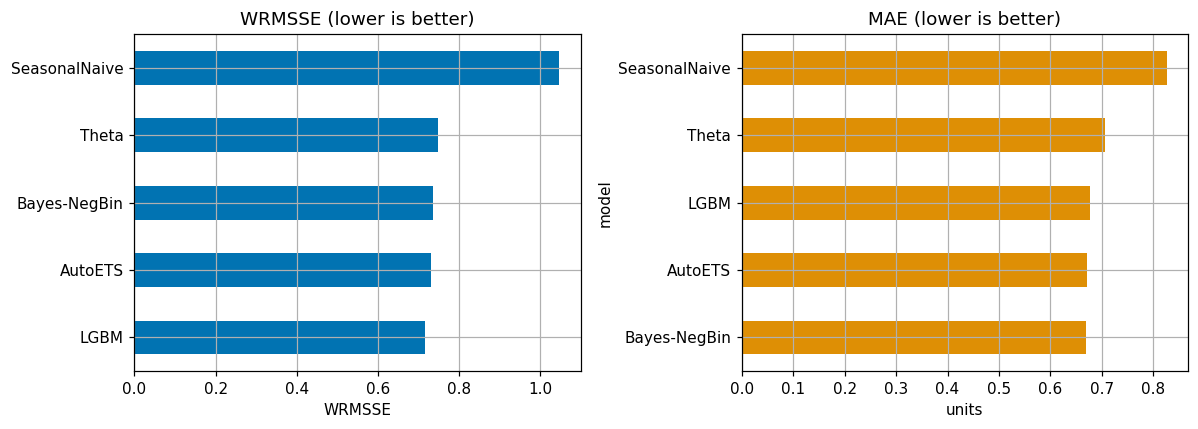

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

wrmsse.sort_values().plot(kind="barh", ax=axes[0], color="C0")
axes[0].set_title("WRMSSE (lower is better)")
axes[0].set_xlabel("WRMSSE")

accuracy["MAE"].sort_values().plot(kind="barh", ax=axes[1], color="C1")
axes[1].set_title("MAE (lower is better)")
axes[1].set_xlabel("units")

plt.tight_layout()

In [ ]:
# Per-series WRMSSE for Bayes vs LGBM on the eval panel
from m5.evaluation import wrmsse

per_series = []
for uid in eval_ids:
    sub = cv_all.loc[cv_all["unique_id"] == uid]
    t = sub[["unique_id", "ds", "y"]]
    comp = compute_components(long.loc[(long["unique_id"] == uid) & (long["ds"] <= train_cutoff)])
    per_series.append(
        {
            "unique_id": uid,
            "Bayes-NegBin": wrmsse(t, sub.rename(columns={"Bayes-NegBin": "y_hat"}), comp, forecast_col="y_hat"),
            "LGBM": wrmsse(t, sub.rename(columns={"LGBM": "y_hat"}), comp, forecast_col="y_hat"),
            "Theta": wrmsse(t, sub.rename(columns={"Theta": "y_hat"}), comp, forecast_col="y_hat"),
        }
    )

per_series_df = pd.DataFrame(per_series).set_index("unique_id")
per_series_df["Bayes - LGBM"] = per_series_df["Bayes-NegBin"] - per_series_df["LGBM"]
per_series_df.sort_values("Bayes - LGBM")

,Bayes-NegBin,LGBM,Theta,Bayes - LGBM
unique_id,,,,
FOODS_1_001_TX_1,0.581063,0.639046,0.729216,-0.057983
FOODS_1_001_WI_1,0.400761,0.449058,0.684884,-0.048297
FOODS_1_001_WI_3,0.481805,0.504460,0.555054,-0.022656
FOODS_1_001_CA_4,0.438042,0.454286,0.467905,-0.016244
FOODS_1_001_CA_2,0.468089,0.475421,0.595666,-0.007332
FOODS_1_001_WI_2,1.052690,1.056261,1.078901,-0.003571
FOODS_1_001_CA_3,0.492630,0.494034,0.482989,-0.001404
FOODS_1_002_CA_4,0.589028,0.586957,0.633042,0.002070
FOODS_1_002_TX_1,1.601332,1.598987,1.610653,0.002345


### Reading the results

- **WRMSSE** is the competition metric — dollar-weighted, scale-normalised RMSE. Compare on the same eval panel only; absolute levels depend on which series were sampled.
- **Bayes-NegBin** uses the same calendar/price covariates as the LGBM feature menu but fits **per-series** MCMC — no global pooling across the 30k panel.
- Expect Bayes to trail **LGBM** and **Theta** on WRMSSE here; its value is **calibrated uncertainty** (see `01_hierarchical_negbin.ipynb`) rather than point accuracy at scale.
- To scale up: increase `EVAL_N_SERIES`, run `N_WINDOWS=3`, or move to variational partial pooling (roadmap in notebook 01).